# First we will install our libaries and see what we will need

In [197]:
!pip install catboost
from IPython.display import clear_output

!pip install dask[dataframe] catboost

clear_output()


In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import zipfile

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Now importing our own data from kaggle (no need to download the file (Python magic)

In [199]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'noshowappointments' dataset.
Path to dataset files: /kaggle/input/noshowappointments


# First we will do EDA to explore our data and see the smallest details—such as the relationships between columns and the presence of null or imbalanced values—given that we are dealing with big data.

In [200]:
csv_path = os.path.join(path, "KaggleV2-May-2016.csv")

df_medical = pd.read_csv(csv_path)
df_medical.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [201]:
df_medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [202]:
df_medical.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


# we need to see the realations between columns in general

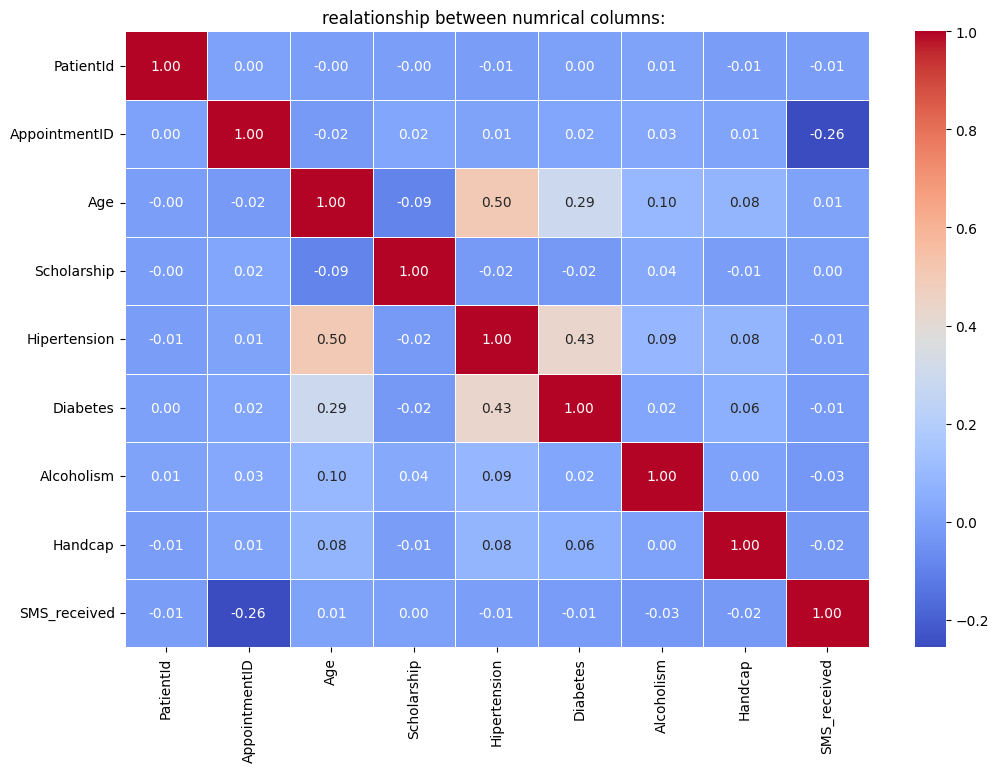

In [203]:
numeric_df = df_medical.select_dtypes(include=['int64', 'float64'])

# 2. حساب مصفوفة الارتباط
corr_matrix = numeric_df.corr()

# 3. رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,       # لإظهار الأرقام داخل المربعات
            cmap='coolwarm',  # اختيار ألوان توضح الموجب والسالب
            fmt=".2f",        # تقريب الأرقام لفاصلتين عشريتين
            linewidths=0.5)

plt.title("realationship between numrical columns: ")
plt.show()

## See here we have outliers so you can either exclude them or keep them—the choice is yours—but you must be aware that some outliers are illogical (such as a negative age value), in which case you should remove them.

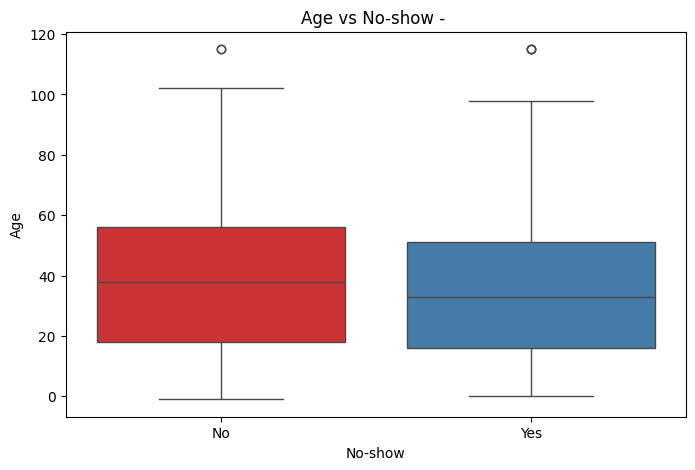

In [204]:
# رسم 2: العلاقة بين العمر والغياب (رقمي مع فئوي)
if 'Age' in df_medical.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='No-show', y='Age', data=df_medical, palette='Set1')
    plt.title('Age vs No-show - ')
    plt.show()

In [205]:
df_medical.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


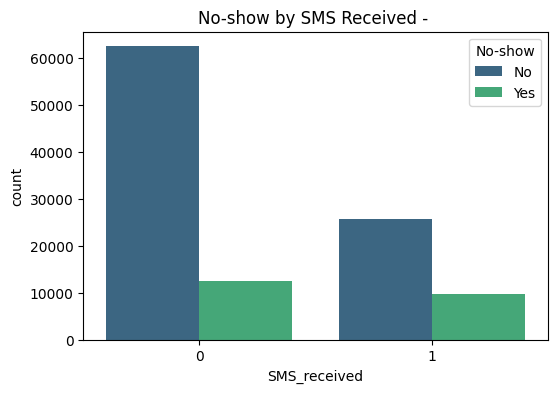

In [206]:
if 'SMS_received' in df_medical.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x='SMS_received', hue='No-show', data=df_medical, palette='viridis')
        plt.title('No-show by SMS Received - ')
        plt.show()

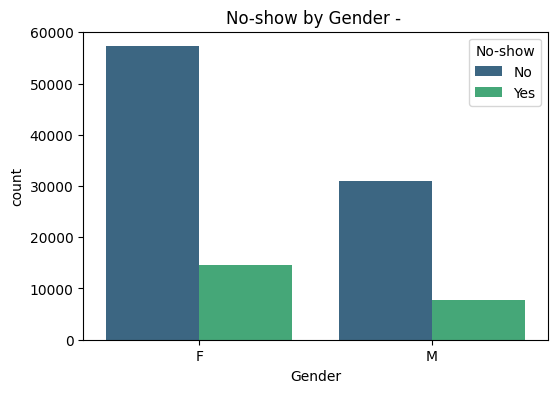

In [207]:
if 'Gender' in df_medical.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x='Gender', hue='No-show', data=df_medical, palette='viridis')
        plt.title('No-show by Gender - ')
        plt.show()

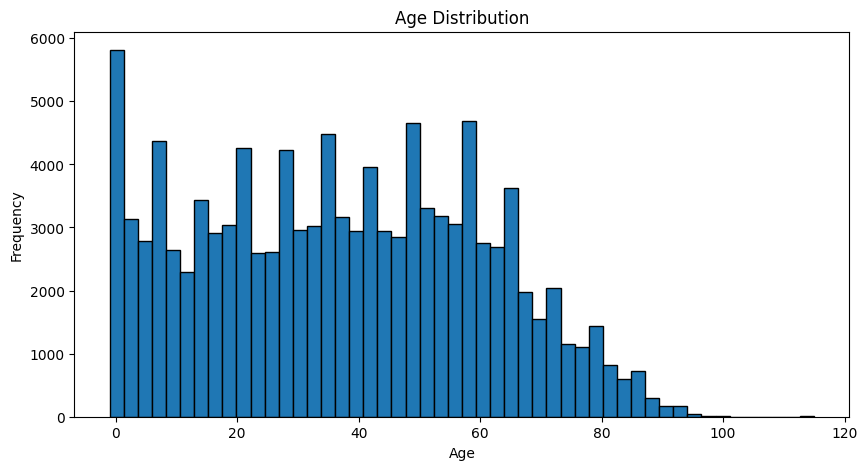

In [208]:
plt.figure(figsize=(10, 5))
plt.hist(df_medical['Age'].dropna(), bins=50, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [209]:
df_medical.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


# We have imbalanced data.

In [210]:
df_medical['No-show'].value_counts()

,count
No-show,
No,88208
Yes,22319


# Unrealistec stats , Age = -1 !

In [211]:
sum(df_medical.duplicated())

0

In [212]:
print(sorted(df_medical.Age.unique()))

[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), n

In [213]:
# الأعمدة التي تحتاج لمعالجة القيم الشاذة
columns_to_fix = ['Age']

# حلقة تكرارية للمرور على الأعمدة وتصفيتها
for col in columns_to_fix:
    # تحديد الحد الأدنى (1%) والحد الأعلى (99%)
    q_low = df_medical[col].quantile(0.01)
    q_hi  = df_medical[col].quantile(0.99)

    # فلترة الإطار ليبقى فقط ضمن النطاق المنطقي
    df_medical = df_medical[(df_medical[col] >= q_low) & (df_medical[col] <= q_hi)]

print("تم تنظيف القيم الشاذة بنجاح!")

تم تنظيف القيم الشاذة بنجاح!


In [214]:
df_medical.drop(columns= ["AppointmentID", "PatientId"], axis = 1, inplace = True)
# axis =1 means your are in columns but if you want to be on rows you choose 0 instead of 1
df_medical.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# #you can change the names of columns using df.rename(columns = {old column: new column}, inplace = True)

## Now lets change the data type of time to be easy to read.

In [215]:
df_medical['ScheduledDay'] = pd.to_datetime(df_medical['ScheduledDay'])
df_medical['AppointmentDay'] = pd.to_datetime(df_medical['AppointmentDay'])

In [216]:
df_medical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109626 entries, 0 to 110526
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   Gender          109626 non-null  object             
 1   ScheduledDay    109626 non-null  datetime64[ns, UTC]
 2   AppointmentDay  109626 non-null  datetime64[ns, UTC]
 3   Age             109626 non-null  int64              
 4   Neighbourhood   109626 non-null  object             
 5   Scholarship     109626 non-null  int64              
 6   Hipertension    109626 non-null  int64              
 7   Diabetes        109626 non-null  int64              
 8   Alcoholism      109626 non-null  int64              
 9   Handcap         109626 non-null  int64              
 10  SMS_received    109626 non-null  int64              
 11  No-show         109626 non-null  object             
dtypes: datetime64[ns, UTC](2), int64(7), object(3)
memory usage: 10.9+ MB


In [217]:
df_medical

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...
110522,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [218]:
#Now let's make it more easier
df_medical.AppointmentDay.dt.strftime('%y-%m-%d').unique()



array(['16-04-29', '16-05-03', '16-05-10', '16-05-17', '16-05-24',
       '16-05-31', '16-05-02', '16-05-30', '16-05-16', '16-05-04',
       '16-05-19', '16-05-12', '16-05-06', '16-05-20', '16-05-05',
       '16-05-13', '16-05-09', '16-05-25', '16-05-11', '16-05-18',
       '16-05-14', '16-06-02', '16-06-03', '16-06-06', '16-06-07',
       '16-06-01', '16-06-08'], dtype=object)

In [219]:
df_medical.ScheduledDay.dt.strftime('%y-%m-%d').unique()

array(['16-04-29', '16-04-27', '16-04-26', '16-04-28', '16-04-25',
       '16-04-20', '16-03-31', '16-04-19', '16-04-06', '16-04-18',
       '16-04-11', '16-04-12', '16-04-15', '16-04-01', '16-04-05',
       '16-04-08', '16-04-14', '16-04-13', '16-04-07', '16-03-17',
       '16-03-30', '16-03-29', '16-03-18', '16-03-28', '16-03-04',
       '16-03-15', '16-03-14', '16-03-21', '16-03-23', '16-03-22',
       '16-03-16', '16-03-10', '16-02-29', '16-03-08', '16-03-07',
       '16-02-24', '16-02-22', '16-01-29', '16-02-23', '16-02-11',
       '16-02-02', '16-01-05', '16-01-11', '16-02-26', '16-02-19',
       '16-02-17', '16-02-05', '16-03-03', '16-03-02', '16-03-09',
       '16-03-01', '16-03-19', '16-03-11', '16-02-16', '16-02-25',
       '16-04-09', '16-05-24', '16-05-25', '16-05-31', '16-05-17',
       '16-05-30', '16-05-12', '16-05-19', '16-05-10', '16-05-02',
       '16-05-16', '16-05-04', '16-05-13', '16-05-20', '16-05-05',
       '16-05-18', '16-05-06', '16-05-09', '16-05-03', '16-05-

In [220]:
df_medical

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...
110522,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Hipertension'}>],
       [<Axes: title={'center': 'Diabetes'}>,
        <Axes: title={'center': 'Alcoholism'}>],
       [<Axes: title={'center': 'Handcap'}>,
        <Axes: title={'center': 'SMS_received'}>]], dtype=object)

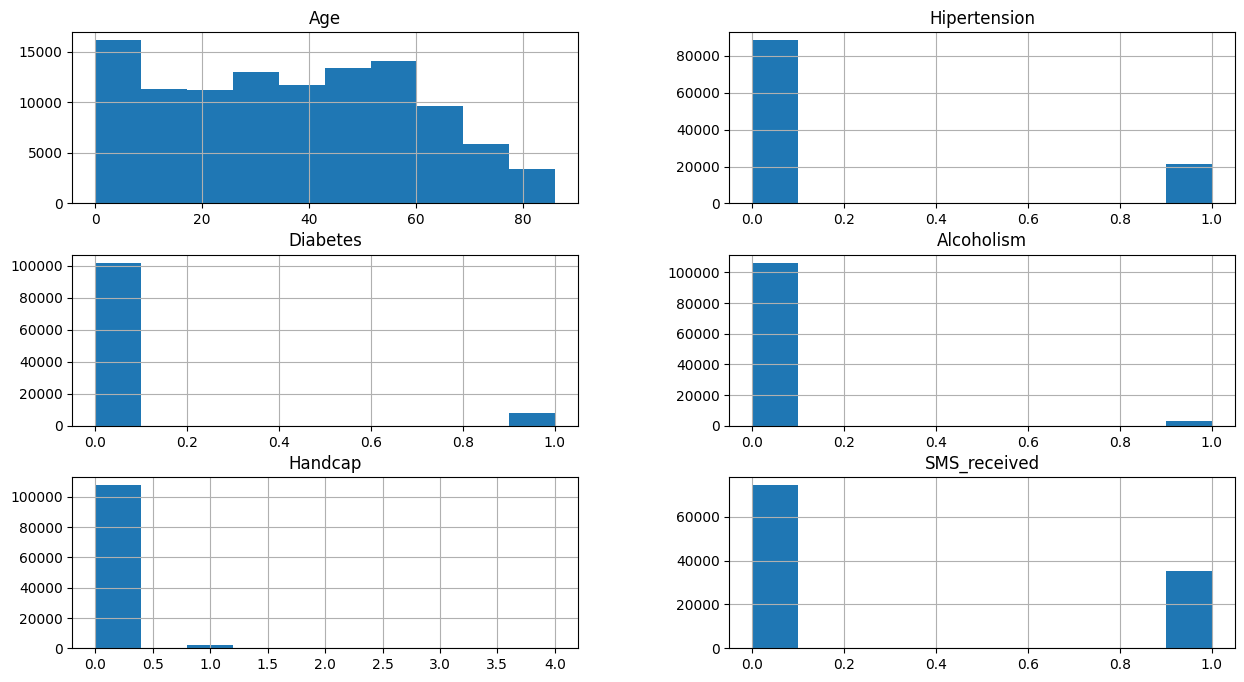

In [221]:
df_draw = df_medical[['Age', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']]
df_draw.hist(figsize=(15,8))

Text(0, 0.5, 'Number of no and yes')

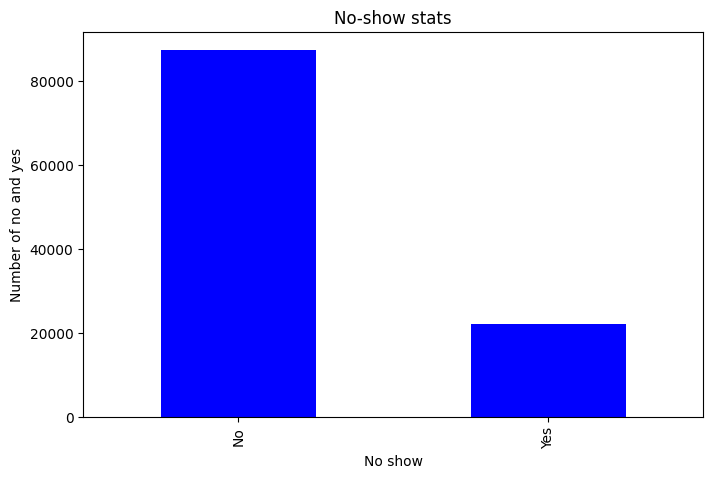

In [222]:
df_medical['No-show'].value_counts().plot.bar(figsize = (8,5), title = 'No-show stats', color = 'b')
plt.xlabel('No show')
plt.ylabel('Number of no and yes')

Text(0, 0.5, 'Number of emale and males')

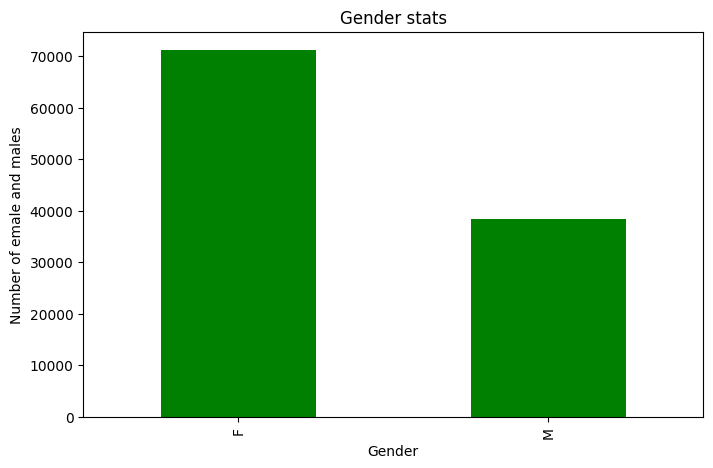

In [223]:
df_medical['Gender'].value_counts().plot.bar(figsize = (8,5), title = 'Gender stats', color = 'Green')
plt.xlabel('Gender')
plt.ylabel('Number of emale and males')

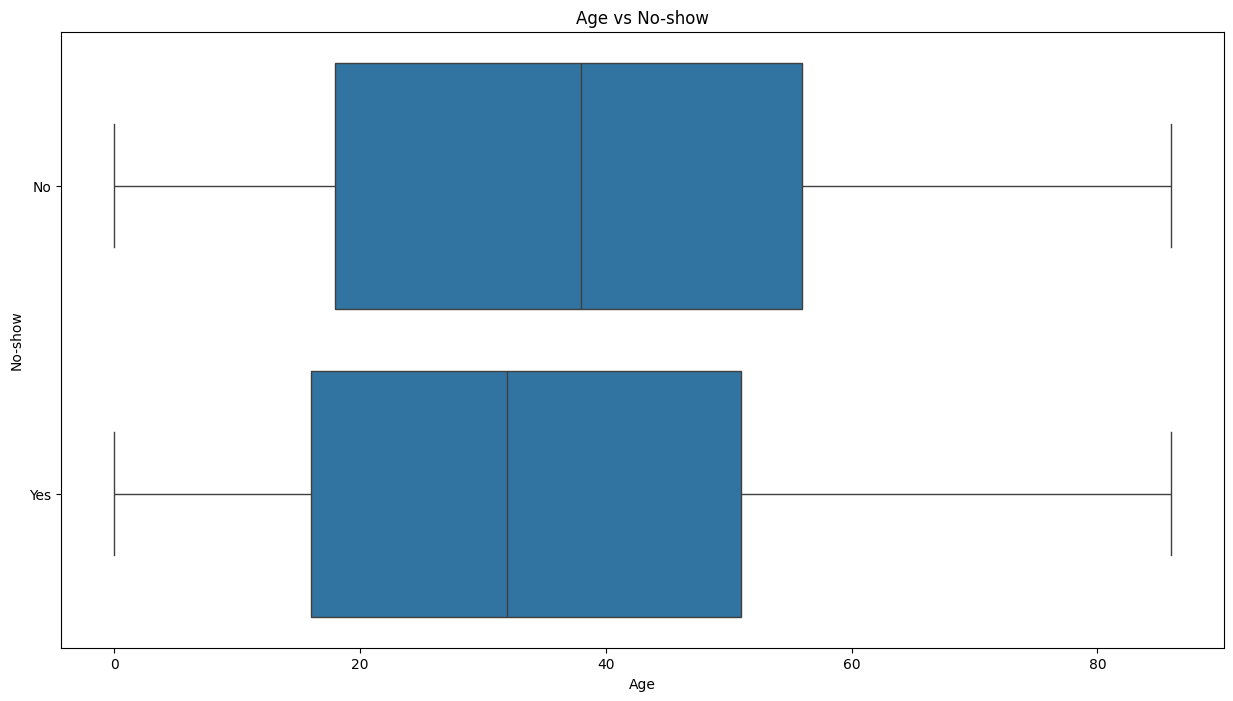

In [224]:
plt.figure(figsize = (15,8))
age = sns.boxplot(x = df_medical.Age, y = df_medical['No-show']).set_title('Age vs No-show')

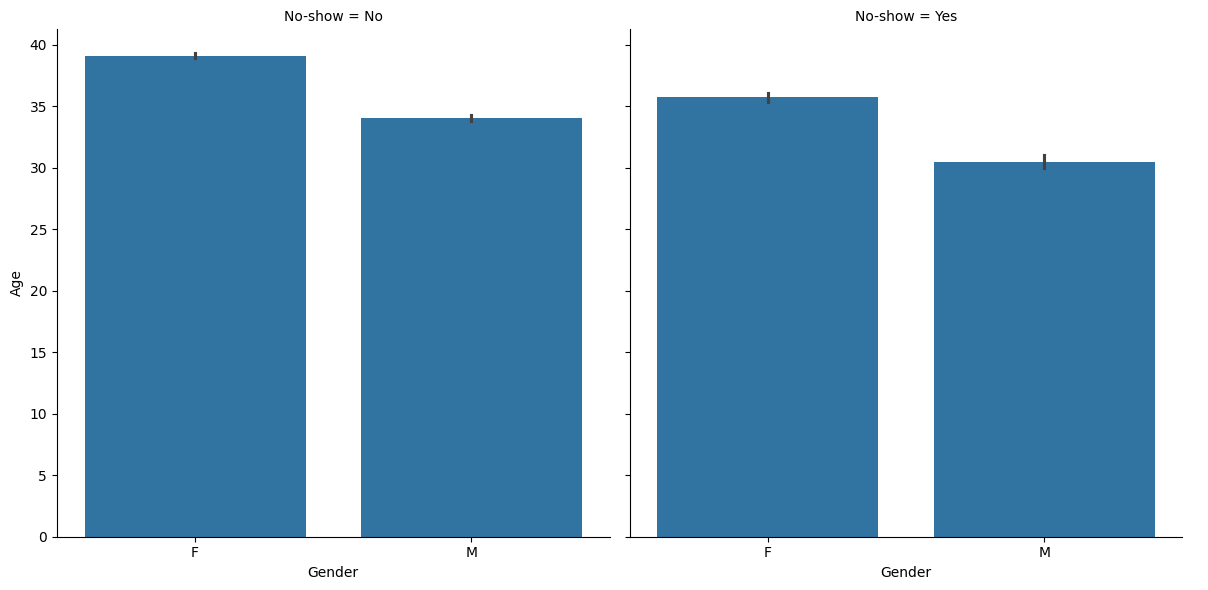

In [225]:
sns.catplot(x = "Gender", y = "Age", col = "No-show", data = df_medical, height=6, kind = 'bar')

In [226]:
df_medical

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...
110522,F,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,F,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,F,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,F,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [227]:

df_medical['ScheduledDay'] = pd.to_datetime(df_medical['ScheduledDay'])
df_medical['AppointmentDay'] = pd.to_datetime(df_medical['AppointmentDay'])
# استخراج "أيام الانتظار" (الفرق بين الموعد ويوم الحجز)
df_medical['WaitingDays'] = (df_medical['AppointmentDay'].dt.normalize() - df_medical['ScheduledDay'].dt.normalize()).dt.days

# ملاحظة: أحياناً يكون هناك أخطاء في البيانات (تاريخ الحجز بعد تاريخ الموعد فتكون النتيجة بالسالب)
# يفضل تصفية هذه الأخطاء إن وجدت
df_medical = df_medical[df_medical['WaitingDays'] >= 0]

#  استخراج "يوم الأسبوع" للموعد (0 = الإثنين، 6 = الأحد)
df_medical['Appointment_DayOfWeek'] = df_medical['AppointmentDay'].dt.dayofweek

#  الآن استخرجنا الفائدة، يمكننا حذف أعمدة التواريخ الأصلية بأمان لأن النموذج لا يقرأها
df_medical = df_medical.drop(['ScheduledDay', 'AppointmentDay'], axis=1)

# بعد هذه الخطوات، يمكنك تقسيم البيانات إلى X و y، ثم تطبيق OneHotEncoder براحة تامة!

## We removed the 'Neighbourhood' column because, when running the learning model, it became apparent that this column wastes resources and distracts the model rather than benefiting it; its impact on the results is negligible, which is why I revisited this step and removed it.

In [228]:
X = df_medical.drop(['No-show', 'Neighbourhood'], axis=1)
y = df_medical['No-show']

# 2. تقسيم البيانات إلى تدريب (80%) واختبار (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# طباعة الأبعاد للتأكد من نجاح التقسيم
print("شكل بيانات التدريب X_train:", X_train.shape)
print("شكل بيانات الاختبار X_test:", X_test.shape)
print("شكل بيانات التدريب y_train:", y_train.shape)
print("شكل بيانات الاختبار y_test:", y_test.shape)

شكل بيانات التدريب X_train: (87696, 10)
شكل بيانات الاختبار X_test: (21925, 10)
شكل بيانات التدريب y_train: (87696,)
شكل بيانات الاختبار y_test: (21925,)


In [229]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. تحويل المتغير المستهدف (y) إلى أرقام إذا لم تقم بذلك مسبقاً
# تحويل 'No' (حضور) إلى 0، و 'Yes' (غياب) إلى 1
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

# 2. تحديد الأعمدة النصية في X التي تحتاج إلى تحويل
categorical_columns = ['Gender']

# 3. إنشاء أداة التحويل (ColumnTransformer)
# نستخدم OneHotEncoder لتحويل النصوص إلى أعمدة من الأصفار والآحاد
# drop='first' يُستخدم لتجنب مشكلة إحصائية تسمى (Dummy Variable Trap)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_columns)
    ],
    remainder='passthrough' # هذه التعليمة تخبر الكود بترك باقي الأعمدة الرقمية (مثل العمر) كما هي دون تغيير
)

# 4. تطبيق التحويل على البيانات
# مهم جداً: نستخدم fit_transform لبيانات التدريب ليتعلم منها
X_train_encoded = preprocessor.fit_transform(X_train)

# ونستخدم transform فقط لبيانات الاختبار لكي يطبق ما تعلمه دون أن يغش منها
X_test_encoded = preprocessor.transform(X_test)

print("تم تحويل البيانات بنجاح!")
print(f"شكل بيانات التدريب الجديدة: {X_train_encoded.shape}")

تم تحويل البيانات بنجاح!
شكل بيانات التدريب الجديدة: (87696, 10)


In [230]:
from sklearn.preprocessing import StandardScaler

# 1. تحديد الأعمدة الرقمية فقط التي تحتاج إلى تقييس (Scale)
# تأكد من وضع أسماء الأعمدة الرقمية الموجودة لديك بدقة
numeric_cols = ['Age', 'WaitingDays', 'Appointment_DayOfWeek']

# 2. إنشاء كائن الـ Scaler
scaler = StandardScaler()

# 3. تطبيق التقييس على بيانات التدريب (يتعلم منها ويحولها)
# نحدد الأعمدة الرقمية فقط لكي لا نؤثر على الأعمدة التي تم عمل Encode لها
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# 4. تطبيق التقييس على بيانات الاختبار (يحولها فقط بناءً على ما تعلمه من التدريب)
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("تم تقييس البيانات بنجاح!")

تم تقييس البيانات بنجاح!


## Here, you can see that we began training the data using models and algorithms such as logistic regression, random forest, and CatBoost. We encountered a common challenge associated with classification tasks: factors beyond our control—such as a person being delayed by traffic or falling ill before an appointment. Since models cannot detect these variables, we turn to advanced algorithms to extract as much useful information as possible for our predictions.

In [231]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pandas as pd


log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# =====================================================================
# 2. التقييم المتقاطع (Cross-Validation) المطابق لـ Stratified K-Fold
# =====================================================================
print("--- نتائج التقييم المتقاطع (Cross Validation) ---")
# cv=5 تعني أنه سيقسم البيانات إلى 5 أقسام لتدريب واختبار النموذج
cv_scores = cross_val_score(log_reg, X_train_encoded, y_train, cv=5, scoring='accuracy')

print(f"دقة كل قسم من الأقسام الخمسة: {cv_scores}")
print(f"(Mean Accuracy): {cv_scores.mean():.4f}")
print(f"الانحراف المعياري (Standard Deviation): {cv_scores.std():.4f}")
print("="*50 + "\n")

--- نتائج التقييم المتقاطع (Cross Validation) ---
دقة كل قسم من الأقسام الخمسة: [0.67109464 0.67233024 0.66417698 0.67284338 0.66947945]
(Mean Accuracy): 0.6700
الانحراف المعياري (Standard Deviation): 0.0031



## In classification tasks, the recall metric is of paramount importance. It captures instances where a patient missed their appointment but the model predicted they would attend—a scenario that wastes hospital resources and incurs significant financial loss. Therefore, prioritizing an increase in recall is crucial, even if it results in lower overall accuracy.

In [232]:
import pandas as pd
from IPython.display import display

# ==========================================
# 1. تدريب النموذج النهائي والتنبؤ
# ==========================================
log_reg.fit(X_train_encoded, y_train)
y_pred = log_reg.predict(X_test_encoded)

# ==========================================
# 2. عرض إحصائيات تقييم الأداء (Metrics)
# ==========================================
print(" إحصائيات تقييم الأداء (Classification Metrics):")
print("-" * 50)
print(f" (Accuracy) : {accuracy_score(y_test, y_pred):.4f}")
print(f" (Precision) : {precision_score(y_test, y_pred):.4f}")
print(f" (Recall)    : {recall_score(y_test, y_pred):.4f}")
print(f" (F1-Score)  : {f1_score(y_test, y_pred):.4f}")
print("-" * 50 + "\n")

# ==========================================
# 3. إحصائيات النموذج الرياضية والأوزان
# ==========================================
print(f" نقطة التقاطع (Intercept): {log_reg.intercept_[0]:.4f}\n")
print(" أهم العوامل المؤثرة في النموذج (مرتبة حسب الأهمية):")

# استخراج الأسماء والأوزان
feature_names = preprocessor.get_feature_names_out()
coefficients = log_reg.coef_[0]

# وضعها في جدول أنيق (DataFrame) بدلاً من طباعتها بـ for loop
coef_df = pd.DataFrame({
    '(Feature)': feature_names,
    '(Coefficient)': coefficients
})

# ترتيب الجدول لمعرفة أكثر العوامل تأثيراً (سواء إيجاباً أو سلباً)
coef_df = coef_df.sort_values(by='(Coefficient)', key=abs, ascending=False).reset_index(drop=True)


display(coef_df)

 إحصائيات تقييم الأداء (Classification Metrics):
--------------------------------------------------
 (Accuracy) : 0.6697
 (Precision) : 0.3140
 (Recall)    : 0.5611
 (F1-Score)  : 0.4027
--------------------------------------------------

 نقطة التقاطع (Intercept): -0.2822

 أهم العوامل المؤثرة في النموذج (مرتبة حسب الأهمية):


,(Feature),(Coefficient)
0,remainder__SMS_received,0.349600
1,remainder__Scholarship,0.206441
2,remainder__Alcoholism,0.177986
3,remainder__Diabetes,0.139952
4,remainder__Handcap,0.044922
5,remainder__Hipertension,-0.038818
6,remainder__WaitingDays,0.029099
7,remainder__Appointment_DayOfWeek,0.026068
8,cat__Gender_M,-0.013567
9,remainder__Age,-0.007392


In [233]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

# ==========================================
# 1. بناء وتدريب نموذج الغابة العشوائية (Random Forest)
# ==========================================
# n_jobs=-1 تستخدم لتسريع التدريب باستخدام جميع أنوية المعالج
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

rf_model.fit(X_train_encoded, y_train)

# ==========================================
# 2. التنبؤ باستخدام بيانات الاختبار
# ==========================================
# بدلاً من استخدام predict مباشرة، نطلب من النموذج إعطائنا "نسبة الاحتمالية"
y_pred_probs = rf_model.predict_proba(X_test_encoded)[:, 1] # احتمالية الغياب (الفئة 1)

# تغيير حد اتخاذ القرار (Threshold) من 0.50 إلى 0.30
# أي مريض احتمالية غيابه 30% أو أكثر، سنعتبره سيغيب
custom_threshold = 0.30
y_pred_adjusted = (y_pred_probs >= custom_threshold).astype(int)

# طباعة النتائج الجديدة
print(" إحصائيات الأداء بعد تعديل حد اتخاذ القرار (Threshold = 0.30):")
print("-" * 55)
print(f" الدقة الإجمالية (Accuracy) : {accuracy_score(y_test, y_pred_adjusted):.4f}")
print(f" دقة التنبؤ (Precision) : {precision_score(y_test, y_pred_adjusted):.4f}")
print(f" حساسية النموذج (Recall) : {recall_score(y_test, y_pred_adjusted):.4f}")
print(f" المقياس المدمج (F1-Score) : {f1_score(y_test, y_pred_adjusted):.4f}")

# ==========================================
# 4. استخراج أهمية الميزات (Feature Importances)
# ==========================================
print(" أهم العوامل المؤثرة في النموذج (مرتبة حسب قوة تأثيرها على القرار):")

# استخراج الأسماء وقيم الأهمية
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

# وضعها في جدول أنيق (DataFrame)
importance_df = pd.DataFrame({
    '(Feature)': feature_names,
    '(Importance)': importances
})

# ترتيب الجدول لمعرفة أكثر العوامل تأثيراً (من الأعلى للأقل)
importance_df = importance_df.sort_values(by='(Importance)', ascending=False).reset_index(drop=True)

# عرض الجدول
display(importance_df)

 إحصائيات الأداء بعد تعديل حد اتخاذ القرار (Threshold = 0.30):
-------------------------------------------------------
 الدقة الإجمالية (Accuracy) : 0.6417
 دقة التنبؤ (Precision) : 0.2804
 حساسية النموذج (Recall) : 0.5143
 المقياس المدمج (F1-Score) : 0.3629
 أهم العوامل المؤثرة في النموذج (مرتبة حسب قوة تأثيرها على القرار):


,(Feature),(Importance)
0,remainder__WaitingDays,0.441712
1,remainder__Age,0.411009
2,remainder__Appointment_DayOfWeek,0.065299
3,remainder__SMS_received,0.022061
4,cat__Gender_M,0.019609
5,remainder__Hipertension,0.009068
6,remainder__Scholarship,0.008453
7,remainder__Diabetes,0.008305
8,remainder__Handcap,0.008026
9,remainder__Alcoholism,0.006458


In [234]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
from IPython.display import display

# ==========================================
# 1. إعداد نموذج CatBoost باحترافية
# ==========================================
# استخدمنا إعدادات متقدمة:
# - auto_class_weights='Balanced': يغنينا عن كتابة كود موازنة الفئات يدوياً
# - eval_metric='F1': نطلب من الخوارزمية التركيز على تحسين الـ F1-Score أثناء التدريب
# - depth=6: عمق الشجرة (6 يعتبر مثالياً لمنع الـ Overfitting)
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    eval_metric='F1',
    random_seed=42,
    verbose=100  # لطباعة التقدم كل 100 خطوة فقط بدلاً من زحمة المخرجات
)

# ==========================================
# 2. تدريب النموذج
# ==========================================
print(" جاري تدريب نموذج CatBoost...\n")
cat_model.fit(X_train_encoded, y_train)

# ==========================================
# 3. التنبؤ والتحكم الذكي بنقطة التوازن (Threshold Tuning)
# ==========================================
# بدلاً من التنبؤ الأعمى، نستخرج احتمالية الغياب لنتمكن من التحكم بها
y_pred_probs_cat = cat_model.predict_proba(X_test_encoded)[:, 1]

# نقطة التوازن (Threshold):
# 0.50 (الافتراضي) سيعطيك Accuracy أعلى و Recall أقل.
# 0.45 تمثل نقطة توازن احترافية جداً مع CatBoost لهذه البيانات.
optimal_threshold = 0.45
y_pred_cat = (y_pred_probs_cat >= optimal_threshold).astype(int)

# ==========================================
# 4. عرض إحصائيات تقييم الأداء الشاملة
# ==========================================
print("\n إحصائيات تقييم الأداء لنموذج (CatBoost):")
print("-" * 55)
print(f" (Accuracy) : {accuracy_score(y_test, y_pred_cat):.4f}")
print(f" (Precision) : {precision_score(y_test, y_pred_cat):.4f}")
print(f" (Recall) : {recall_score(y_test, y_pred_cat):.4f}")
print(f" (F1-Score) : {f1_score(y_test, y_pred_cat):.4f}")
print(f" قوة النموذج المطلقة (ROC-AUC): {roc_auc_score(y_test, y_pred_probs_cat):.4f}")
print("-" * 55 + "\n")

# ==========================================
# 5. استخراج أهمية الميزات وعرضها
# ==========================================
print(" أهم العوامل المؤثرة حسب خوارزمية CatBoost:")

feature_names = preprocessor.get_feature_names_out()
cat_importances = cat_model.get_feature_importance()

cat_importance_df = pd.DataFrame({
    'الميزة (Feature)': feature_names,
    'الأهمية (Importance %)': cat_importances
}).sort_values(by='الأهمية (Importance %)', ascending=False).reset_index(drop=True)

display(cat_importance_df)

 جاري تدريب نموذج CatBoost...

0:	learn: 0.7152633	total: 14.3ms	remaining: 11.4s
100:	learn: 0.7224038	total: 1.99s	remaining: 13.7s
200:	learn: 0.7220426	total: 3.43s	remaining: 10.2s
300:	learn: 0.7264280	total: 4.81s	remaining: 7.97s
400:	learn: 0.7296453	total: 6.19s	remaining: 6.16s
500:	learn: 0.7313233	total: 7.68s	remaining: 4.58s
600:	learn: 0.7334014	total: 9.07s	remaining: 3s
700:	learn: 0.7350943	total: 10.5s	remaining: 1.48s
799:	learn: 0.7366397	total: 11.9s	remaining: 0us

 إحصائيات تقييم الأداء لنموذج (CatBoost):
-------------------------------------------------------
 (Accuracy) : 0.5475
 (Precision) : 0.2884
 (Recall) : 0.8729
 (F1-Score) : 0.4336
 قوة النموذج المطلقة (ROC-AUC): 0.7314
-------------------------------------------------------

 أهم العوامل المؤثرة حسب خوارزمية CatBoost:


,الميزة (Feature),الأهمية (Importance %)
0,remainder__WaitingDays,55.482116
1,remainder__Age,21.639158
2,remainder__Appointment_DayOfWeek,7.513172
3,cat__Gender_M,3.607894
4,remainder__SMS_received,2.257277
5,remainder__Hipertension,2.250778
6,remainder__Handcap,2.196007
7,remainder__Scholarship,1.924032
8,remainder__Diabetes,1.692326
9,remainder__Alcoholism,1.437241
